# Phase 1 — Data Acquisition
**House Price Prediction — Regression Capstone**

This notebook loads the Kaggle House Prices dataset, performs an initial audit, and documents basic statistics.

In [1]:
import pandas as pd
import numpy as np
import os

# Paths
DATA_DIR = os.path.join("..", "data", "raw")
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (1460, 81)
Test shape: (1459, 80)


In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
dtypes = train.dtypes.value_counts()
print("=== Data Type Counts ===")
for dt, count in dtypes.items():
    print(f"  {dt}: {count} columns")

=== Data Type Counts ===
  object: 43 columns
  int64: 35 columns
  float64: 3 columns


In [5]:
nulls = train.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print("=== Columns with Missing Values ===")
for col, count in nulls.items():
    print(f"  {col}: {count} ({count/len(train)*100:.1f}%)")

=== Columns with Missing Values ===
  PoolQC: 1453 (99.5%)
  MiscFeature: 1406 (96.3%)
  Alley: 1369 (93.8%)
  Fence: 1179 (80.8%)
  MasVnrType: 872 (59.7%)
  FireplaceQu: 690 (47.3%)
  LotFrontage: 259 (17.7%)
  GarageType: 81 (5.5%)
  GarageYrBlt: 81 (5.5%)
  GarageFinish: 81 (5.5%)
  GarageQual: 81 (5.5%)
  GarageCond: 81 (5.5%)
  BsmtExposure: 38 (2.6%)
  BsmtFinType2: 38 (2.6%)
  BsmtQual: 37 (2.5%)
  BsmtCond: 37 (2.5%)
  BsmtFinType1: 37 (2.5%)
  MasVnrArea: 8 (0.5%)
  Electrical: 1 (0.1%)


In [6]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
train[numeric_cols].describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


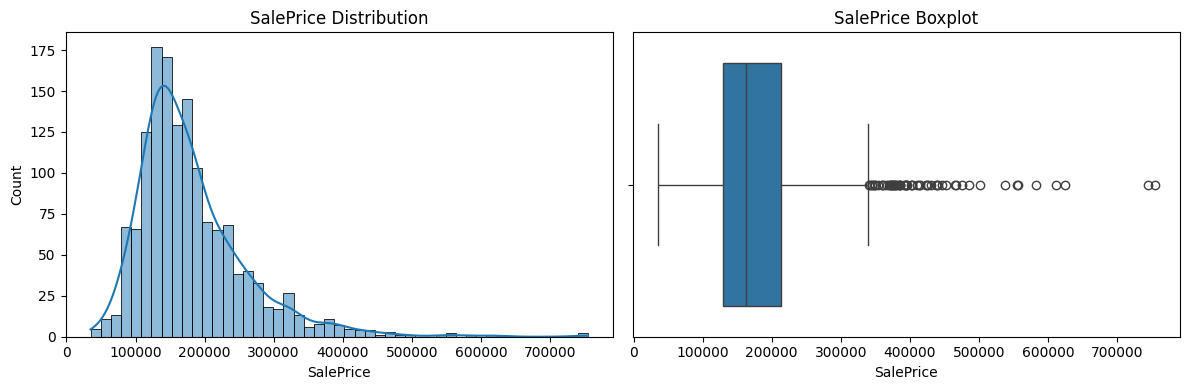

Skewness: 1.88
Kurtosis: 6.54


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice Distribution")
sns.boxplot(x=train["SalePrice"], ax=axes[1])
axes[1].set_title("SalePrice Boxplot")
plt.tight_layout()
plt.show()
print("Skewness: " + str(round(train["SalePrice"].skew(), 2)))
print("Kurtosis: " + str(round(train["SalePrice"].kurtosis(), 2)))


In [8]:
print("Dataset loaded and described successfully.")

Dataset loaded and described successfully.
